In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers
random.seed(1)  # For reproducibility

In [2]:
#Function from data to bpc
# Assumed P controller with gain K
def data_to_bpc(u,x,K):
    A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num, den = gapMetrics.ss_to_tf_discrete(A_hat, B_hat, C, D)
    Abk = A_hat - B_hat * K
    num3, den3 = gapMetrics.ss_to_tf_discrete(Abk, B_hat, C, D)
    bpc, _, _ = gapMetrics.vgap_bpc(num, den, num3, den3)
    return bpc

#
def data_to_vgap(u1, x1, u2, x2):
    A_hat1, B_hat1 = gapMetrics.estimate_AB(u1.T, x1.T)
    A_hat2, B_hat2 = gapMetrics.estimate_AB(u2.T, x2.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num1, den1 = gapMetrics.ss_to_tf_discrete(A_hat1, B_hat1, C, D)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A_hat2, B_hat2, C, D)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

def direct_vgap(A1, B1, C1, D1, A2, B2, C2, D2):
    num1, den1 = gapMetrics.ss_to_tf_discrete(A1, B1, C1, D1)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A2, B2, C2, D2)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

In [3]:
#LQR wrapper

def LQR_wrapper(u,x):
    Q = np.eye(2)
    Q[1, 1] = 1
    R = np.eye(1)*1 #TODO: can adapt to n change
    T_d = 20  #data length for LQR
    U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
    X0 = x[0:T_d, :].T # shape (n, T)  == X_{0,T}
    X1 = x[1:T_d+1, :].T # shape (n, T)  == X_{1,T}
    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
    return K_control

In [3]:
#for test
def random_discrete_system_stable(n=2, m=1, p=1, max_tries=2000, rho_target=0.5):
    for _ in range(max_tries):
        A = np.random.randn(n, n)
        # scale to target spectral radius
        eigs = np.linalg.eigvals(A)
        rho = np.max(np.abs(eigs))
        if rho == 0:
            continue
        if rho > 1.0:
            A = (rho_target / rho) * A

        B = np.random.randn(n, m)
        C = np.random.randn(p, n)
        D = np.zeros((p, m))

        if gapMetrics.is_controllable(A, B) and gapMetrics.is_observable(A, C):
            return A, B, C, D
    raise RuntimeError("Failed to find controllable & observable stable system.")

In [52]:
#generate some random systems
num_systems = 20
T = 50 #number of data points each system
L = 20  #Hankel matrix depth; 15 before
C = np.array([[0.5, 1]])
D = np.array([[0]])
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
stored_hankels = np.empty((num_systems, num_systems), dtype=object)  # To store Hankel matrices of all systems
H_u = gapMetrics.hankel_matrix(u, L)
#Check rank of H_u
rank_H_u = np.linalg.matrix_rank(H_u)
if rank_H_u < L:
    print(f"Warning: Hankel matrix of input has rank {rank_H_u} which is less than L={L}.")
else:
    print(f"Hankel matrix of input has full rank {rank_H_u}.")
#store x for LQR related
stored_x = []
#store A and B for checking
stored_A = []
stored_B = []
stored_param1 = []
stored_param2 = []
params_1 = bacteriaSys.default_params_2()
random.seed(1) #for reproducibility
for i in range(num_systems):
    for j in range(num_systems):
        random_params_1 = params_1["deltam"] - 0.04 + 0.08/num_systems * i
        stored_param1.append(random_params_1)
        # print("deltam:", random_params_1)
        random_params_2 = params_1["deltaM"] - 0.01 + 0.02/num_systems * j
        stored_param2.append(random_params_2)
        # print("deltaM:", random_params_2)
        # print("Generating system", i+1, "with params:", random_params_1, random_params_2)
        A, B =bacteriaSys.discretize_AB(random_params_1, random_params_2, 1.0)
        # A, B, C, D = gapMetrics.random_discrete_system_stable(n=2, m=1, p=1)
        # A, B, _, _ = random_discrete_system_stable(n=2, m=1, p=1, rho_target=0.5)
        # print("A matrix:\n", A)
        # print("B matrix:\n", B)
        x, y = gapMetrics.simulate_system(A, B, C, D, u)
        # print("y shape:", y.shape)
        H_y = gapMetrics.hankel_matrix(y, L)
        H = np.vstack([H_u, H_y])
        stored_x.append(x)
        stored_hankels[i, j] = H
        stored_A.append(A)
        stored_B.append(B)
        if i == num_systems/2 and j == num_systems/2:
            print("Example system at midpoint of parameter grid:")
            print("deltam:", random_params_1)
            print("deltaM:", random_params_2)
            H_ref = H

Hankel matrix of input has full rank 20.
Example system at midpoint of parameter grid:
deltam: 0.14
deltaM: 0.02


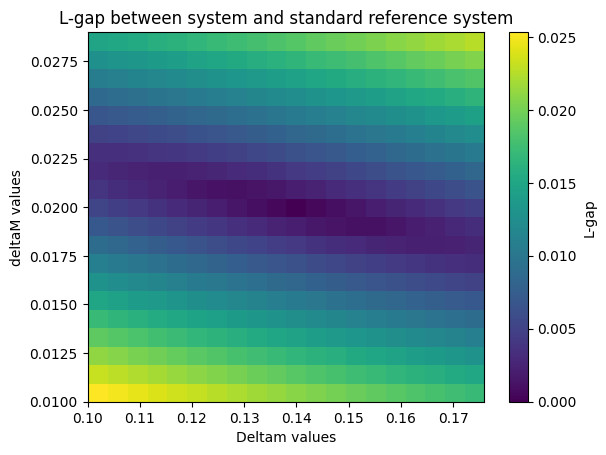

In [53]:
#compute L gaps
m = 1      # number of inputs
n = 2      # state dimension
D_l = np.zeros((num_systems, num_systems))
for i in range(num_systems):
    for j in range(num_systems):
        gij, *_ = gapMetrics.Lgap_metric(stored_hankels[i,j], H_ref, m, n, L, use_alt_formula=False)
        D_l[i, j] = gij

plt.figure()
plt.imshow(
    D_l,
    interpolation="nearest",
    aspect="auto",
    extent=[min(stored_param1), max(stored_param1),
            min(stored_param2), max(stored_param2)],
    origin="lower"
)

plt.colorbar(label="L-gap")
plt.title("L-gap between system and standard reference system")
plt.xlabel("Deltam values")
plt.ylabel("deltaM values")
plt.show()

In [25]:
def leader_groups(D, threshold):
    """
    Star clustering: each group has a leader c, and all members i satisfy D[i,c] <= threshold.
    Greedy: choose leader that covers the most uncovered nodes.
    Returns list of dicts: [{"leader": c, "members": [...]}]
    """
    N = D.shape[0]
    uncovered = set(range(N))
    groups = []

    # Precompute who is within threshold of whom (including self)
    within = [set(np.where(D[i] <= threshold)[0].tolist()) for i in range(N)]

    while uncovered:
        # choose leader that covers most uncovered nodes
        best_leader = None
        best_cover = set()
        for i in uncovered:
            cover = within[i] & uncovered
            if len(cover) > len(best_cover):
                best_cover = cover
                best_leader = i

        members = sorted(best_cover)
        groups.append({"leader": int(best_leader), "members": [int(x) for x in members]})

        # mark them covered
        for x in best_cover:
            uncovered.remove(x)

    return groups


In [ ]:
#better method (TODO: improve timing)
def medoid(D, indices):
    """
    D: (N,N) distance matrix
    indices: iterable of system indices (e.g. uncovered systems)

    Returns:
        leader index (int)
    """
    U = np.array(sorted(indices))  # sorted for determinism
    subD = D[np.ix_(U, U)]          # distances restricted to U × U

    # average distance from each candidate to others in U
    mean_dist = subD.mean(axis=1)
    # TODO: fix number of group members?

    # index of minimum mean distance
    leader = int(U[np.argmin(mean_dist)])
    return leader

def leader_groups2(D):
    N = D.shape[0]
    uncovered = set(range(N))
    groups = []

    while uncovered:
        # 1) pick central leader
        leader = medoid(D, uncovered)
        U = np.array(sorted(uncovered))
        dists = D[leader, U]
        # 2) find leader-specific threshold
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        threshold = data_to_bpc(u, stored_x[leader], K)
        print("Threshold for leader", leader, ":", threshold)
        # 3) assign members
        members = U[dists <= threshold].tolist()
        members = [int(x) for x in members]

        groups.append({
            "leader": leader,
            "eps": threshold,
            "members": members
        })

        # 4) remove covered
        for x in members:
            uncovered.remove(x)

    return groups


In [ ]:
#Clustering with specified m leaders
def pick_leaders(D, m):
    mean_dist = D.mean(axis=1)
    leaders = np.argsort(mean_dist)[:m].astype(int).tolist()  # pick m with smallest mean distance
    thresholds = []
    for leader in leaders:    
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        threshold = data_to_bpc(u, stored_x[leader], K)
        thresholds.append(threshold)
    return leaders, thresholds

def assign_to(D, leaders, thresholds):
    N = D.shape[0]
    leaders = np.asarray(leaders, dtype=int)
    thresholds = np.asarray(thresholds, dtype=float)
    dist = D[:, leaders]  # shape (N, m)
    feasible = dist <= thresholds[None, :]
    leader_of = -np.ones(N, dtype=int)
    dist_to_leader = np.full(N, np.inf, dtype=float)
    for i in range(N):
        ok = np.where(feasible[i])[0]
        if ok.size == 0:
            continue  # remains unassigned
        # among feasible leaders, pick the closest
        kbest = ok[np.argmin(dist[i, ok])]
        leader_of[i] = leaders[kbest]
        dist_to_leader[i] = dist[i, kbest]

    return leader_of, dist_to_leader

def leader_groups_fixed(D, m):
    leaders, thresholds = pick_leaders(D, m)
    leader_of, dist_to_leader = assign_to(D, leaders, thresholds)
    groups = []
    for k, leader in enumerate(leaders):
        members = np.where(leader_of == leader)[0].astype(int).tolist()
        groups.append({
            "leader": int(leader),
            "eps": float(thresholds[k]),
            "members": members
        })
    return groups

In [11]:
#best working method so far
def farthest_seeds(D, m, mode="avg"):
    """
    pick m plants far apart.
    mode:
      - "avg": next seed maximizes average distance to existing plants
      - "min": next seed maximizes minimum distance to existing plants
    """
    N = D.shape[0]
    if m > N:
        raise ValueError("m cannot exceed number of plants")

    # First two: farthest pair
    i0, j0 = np.unravel_index(np.argmax(D), D.shape)
    seeds = [int(i0), int(j0)]

    while len(seeds) < m:
        candidates = [i for i in range(N) if i not in seeds]
        if mode == "avg":
            scores = [float(np.mean(D[i, seeds])) for i in candidates]
        elif mode == "min":
            scores = [float(np.min(D[i, seeds])) for i in candidates]
        else:
            raise ValueError("mode must be 'avg' or 'min'")
        seeds.append(int(candidates[int(np.argmax(scores))]))

    return seeds


def assign_by_smallest_group_average(D, seeds, order="hard_first"):
    """
    Incrementally assign remaining points.
    Each point is assigned to the group that yields smallest average distance to current members.
    """
    N = D.shape[0]
    groups = {s: [s] for s in seeds}  # key=seed id, value=list of members

    remaining = [i for i in range(N) if i not in seeds]

    if order == "hard_first":
        # points farthest from the seed set get assigned first
        seed_arr = np.array(seeds, dtype=int)
        d_to_seedset = np.min(D[:, seed_arr], axis=1)
        remaining.sort(key=lambda i: -d_to_seedset[i])
    elif order == "index":
        pass
    else:
        raise ValueError("order must be 'hard_first' or 'index'")

    for i in remaining:
        best_seed = None
        best_cost = np.inf
        for s, members in groups.items():
            cost = float(np.mean(D[i, members]))  # average distance to group members
            if cost < best_cost:
                best_cost = cost
                best_seed = s
        groups[best_seed].append(int(i))

    return groups  # dict(seed -> members)


def medoid_of_group(D, members):
    """
    Helper: choose leader as medoid (min sum distance within group).
    """
    members = np.array(members, dtype=int)
    subD = D[np.ix_(members, members)]
    k = int(np.argmin(subD.sum(axis=1)))
    return int(members[k])


def build_groups_and_check_thresholds(D, groups_dict):
    """
    Find leader, compute threshold, verify all within threshold.
    threshold_fn(members, leader) -> eps
      If None, eps is treated as +inf (no check).
    try_repair_leader:
      If True, and chosen medoid fails, try any member as leader that passes the threshold.
    """
    out = []
    for seed, members in groups_dict.items():
        leader = medoid_of_group(D, members)
         
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        eps = data_to_bpc(u, stored_x[leader], K)
        dists = D[np.array(members, dtype=int), leader]

        ok = np.all(dists <= eps + 1e-12)

        # if (not ok) and try_repair_leader and threshold_fn is not None:
        #     # try to find any member that makes the group feasible
        #     repaired = False
        #     for cand in members:
        #         eps_c = float(threshold_fn(members, cand))
        #         if np.all(D[np.array(members, dtype=int), cand] <= eps_c + 1e-12):
        #             leader = int(cand)
        #             eps = eps_c
        #             repaired = True
        #             break
        #     ok = repaired

        if not ok:
            # provide a helpful error message
            worst = float(np.max(dists))
            raise ValueError(
                f"Threshold violation for group seeded by {seed}: "
                f"leader={leader}, eps={eps:.4g}, worst_dist={worst:.4g}, size={len(members)}"
            )

        out.append({"seed": int(seed), "leader": int(leader), "eps": float(eps), "members": [int(x) for x in members]})

    return out


# ----- Full pipeline -----

def cluster_farthest_assign_medoid_threshold(D, m, seed_mode="avg",
                                            assign_order="hard_first"):
    """
    Implements 3 steps:
      1) farthest m plants
      2) one-by-one assignment to smallest average distance group
      3) leader = medoid, check all within leader threshold
    """
    seeds = farthest_seeds(D, m, mode=seed_mode)
    groups_dict = assign_by_smallest_group_average(D, seeds, order=assign_order)
    groups = build_groups_and_check_thresholds(D, groups_dict)
    return groups


In [12]:
#automatically find m by checking eps
def clustering_with_auto_m(D, eps, seed_mode="avg", assign_order="hard_first"):
    N = D.shape[0]
    for m in range(1, N+1):
        try:
            print(f"Trying m={m} clusters...")
            groups = cluster_farthest_assign_medoid_threshold(D, m, seed_mode, assign_order)
            check_out = 0
            for g in groups:
                leader = g["leader"]
                members = g["members"]
                condition = all(D[leader, m] < eps for m in members)
                print("leader:", leader, "valid:", condition)
                if not condition:
                    check_out = 1
            if check_out == 0:
                print(f"Successfully clustered with m={m} clusters, eps={eps:.4f}")
                return groups
            elif m == N:
                print(f"All systems in one group with m={m}, eps={groups[0]['eps']:.4f}")
                return groups
        except ValueError as e:
            print(f"Failed with m={m} clusters: {e}")
    raise ValueError("Failed to cluster within threshold for any m.")

In [13]:
def Gap_margin_from_K(K: np.ndarray,Huy: np.ndarray,L: int,tol: float = 1e-10):
    # Graph of controller
    K_prep = K @ np.linalg.pinv(C)
    K_prep = K_prep.T[0]
    print("K_prep shape:", K_prep)
    y = np.zeros((u.shape[0],1))
    print("y shape:", y.shape)
    for i in range(u.shape[0]):
        yi = -K_prep @ u[i]
        y[i,0] = yi
    print("y shape:", y.shape)
    H_Cy_L = gapMetrics.hankel_matrix(y, L)
    H_C_prep = np.vstack([H_u, H_Cy_L])
    print("H_C_prep shape:", H_C_prep.shape)
    print("Hux shape:", Hux.shape)

    gap_val, _, _, _ = gapMetrics.Lgap_metric(Hux, H_C_prep, m, n, L, use_alt_formula=False)
    # print("gap_val:", gap_val)
    margin = 1.0 - gap_val

    return {
        "gap_to_Cperp": gap_val,
        "margin": margin,
    }

K = LQR_wrapper(u, stored_x[7])
Hux = stored_hankels[7]
result = Gap_margin_from_K(K, Hux, L)
print("Gap to C perp:", result["gap_to_Cperp"])
print("Margin:", result["margin"])

K_prep shape: [-8.00179071e-10]
y shape: (50, 1)
y shape: (50, 1)
H_C_prep shape: (40, 31)
Hux shape: (40, 31)
Gap to C perp: 0.9999999956432087
Margin: 4.3567912610953385e-09


In [14]:
# eps = 0.2
# groups = leader_groups(D, eps)
# groups = leader_groups2(D)
# groups = leader_groups_fixed(D, 3)
groups = cluster_farthest_assign_medoid_threshold(D_l, 5)
# groups = clustering_with_auto_m(D_l, eps)
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D_v.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groups:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D_v[leader, i]




K for leader 6 : [[-3.07478200e-09 -6.17825042e-09]]
K for leader 8 : [[2.08018675e-09 2.09179354e-09]]
K for leader 2 : [[-1.54987935e-09  4.22366171e-09]]
K for leader 9 : [[2.40432423e-09 1.23338575e-09]]
K for leader 15 : [[2.69760680e-09 5.93940405e-09]]
leader: 6 size: 2 members: [6, 1]
leader: 8 size: 2 members: [8, 13]
leader: 2 size: 3 members: [17, 12, 2]
leader: 9 size: 4 members: [19, 18, 7, 9]
leader: 15 size: 9 members: [16, 10, 4, 11, 0, 15, 3, 14, 5]


C:\Users\Z PL\AppData\Local\Temp\ipykernel_62392\3890564528.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


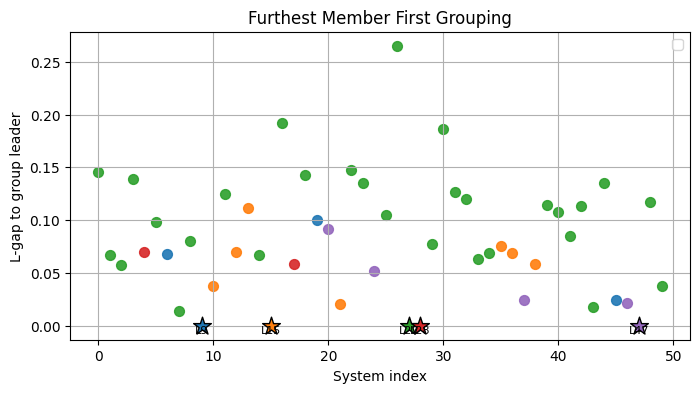

In [42]:
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab10(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

# plt.axhline(eps, linestyle="--", color="gray", label="threshold")
plt.xlabel("System index")
plt.ylabel("L-gap to group leader")
plt.title("Furthest Member First Grouping")
plt.grid(True)
plt.legend()
plt.show()


leader: 28 size: 3 members: [4, 17, 28]
leader: 47 size: 5 members: [20, 24, 37, 46, 47]
leader: 9 size: 4 members: [45, 19, 6, 9]
leader: 27 size: 30 members: [26, 7, 27, 8, 29, 43, 33, 49, 14, 25, 2, 44, 5, 11, 30, 0, 32, 16, 34, 23, 41, 40, 1, 48, 39, 42, 31, 18, 3, 22]
leader: 15 size: 8 members: [13, 36, 12, 38, 35, 10, 15, 21]


Text(0.5, 1.0, "Error under Leader's Controller")

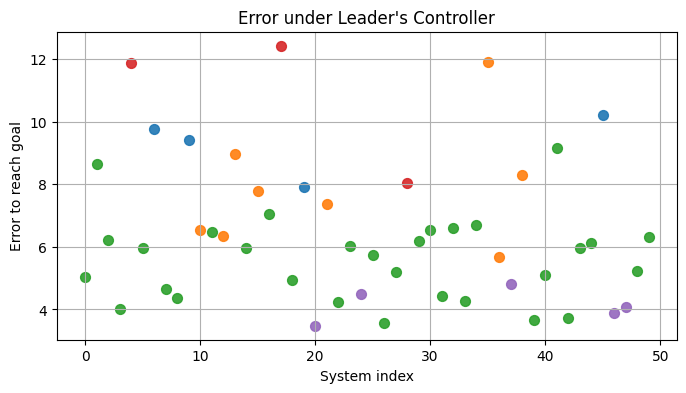

In [43]:
#proof of controllability (new)
def control_effectiveness(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=50):
    """
    N is the number of steps to simulate.
    """
    x = init.copy()
    total_error = 0.0
    for _ in range(N):
        u = -K @ (x - goal)
        x = A @ x + B @ u
        total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
    return total_error
    
error = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    error[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        error[m] = member_error

#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error under Leader's Controller")   

C:\Users\Z PL\AppData\Local\Temp\ipykernel_62392\3525613128.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


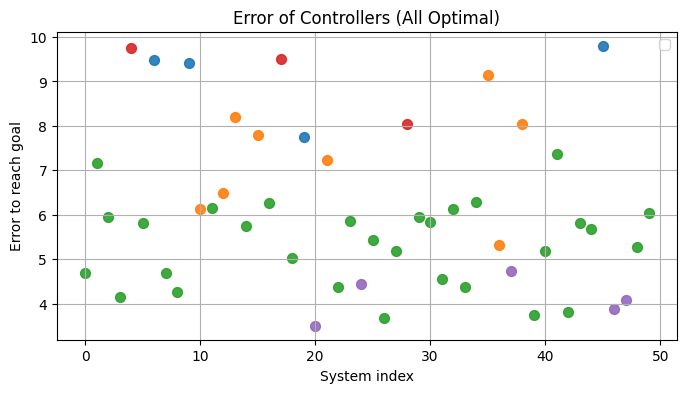

In [44]:
#All optimal example
error_optimal = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error = control_effectiveness(A, B, K)
    error_optimal[i] = error

plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error_optimal[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error of Controllers (All Optimal)")
plt.legend()

w shape: (50, 2)


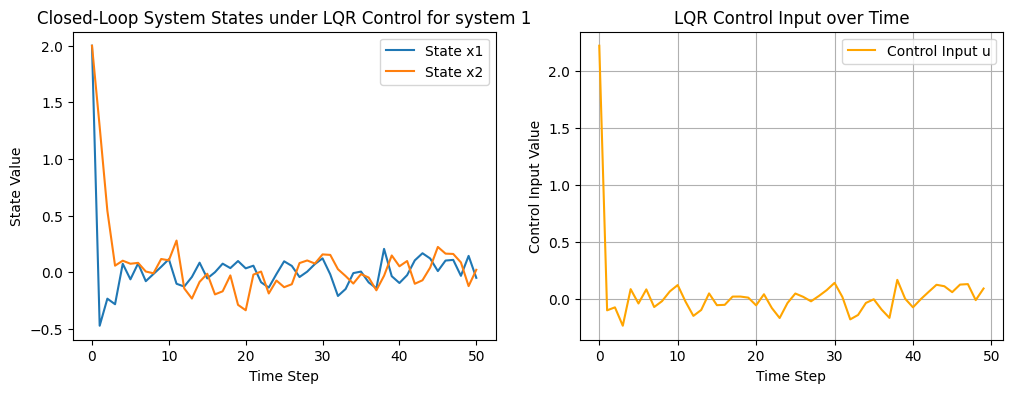

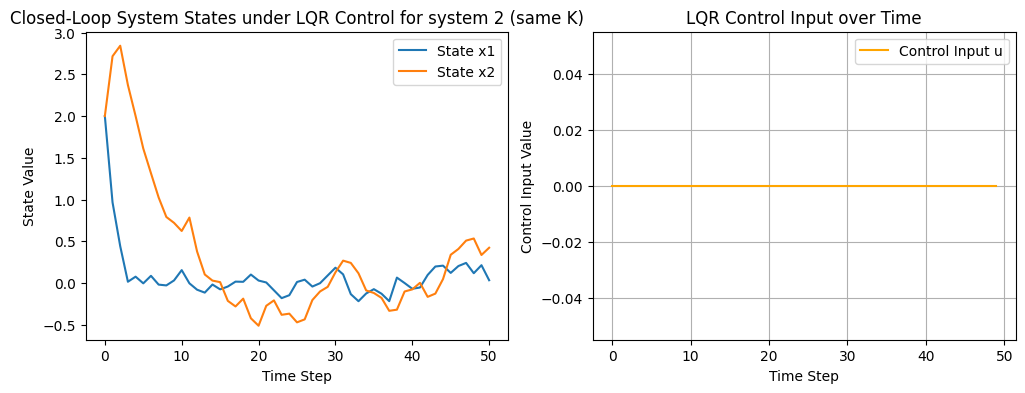

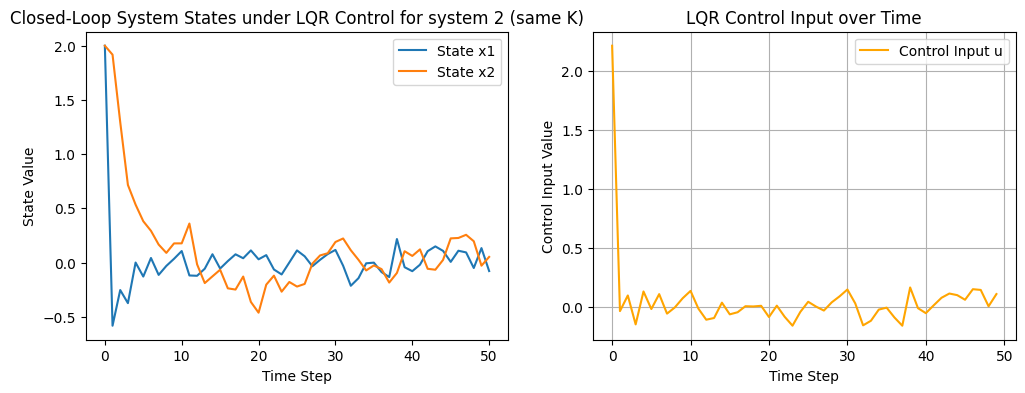

In [38]:
#proof of controllability (old)

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)*0.1
T_d = 20  #data length for LQR

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[7][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[7][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 50 #number of control steps
#disturbance
w = np.random.randn(N, 2).reshape(-1, 2) * 0.1
print("w shape:", w.shape)

x0 = np.array([[2],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[0],[0]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller

for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf) 
    # u_control = np.zeros((1, 1))
    #add disturbance
    x_cl[k+1] = stored_A[7] @ x_cl[k] + stored_B[7] @ u_control
    x_cl[k+1] += w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#system 2
for k in range(N):
    # u_control = -K_control @ (x_cl[k] - xf)
    u_control = np.zeros((1, 1))
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

Leader: 28
K_control shape: (1, 2)
K_control:
 [[1.16517565 0.42633192]]


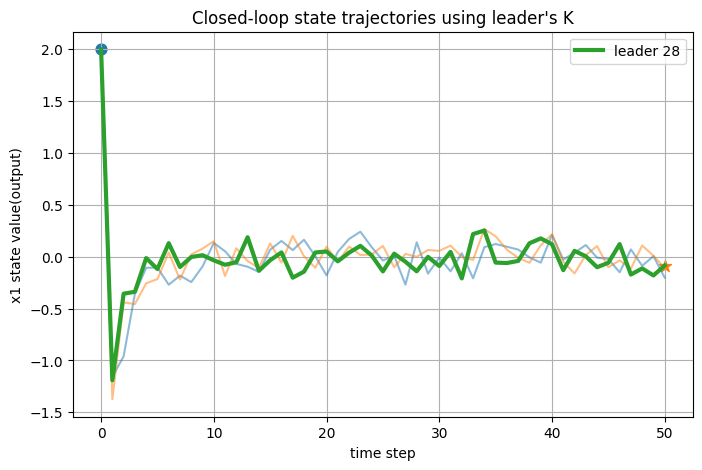

In [47]:
# ----- choose one group only -----
g = groups[0]                 # or any specific group
leader = g["leader"]
members = g["members"]

# ----- LQR settings -----
Q = np.eye(2)
R = np.eye(1) * 0.1
T_d = 20
N = 50

x0 = np.array([[2.0], [2.0]])
xf = np.array([[0.0], [0.0]])

# ----- compute K only from the leader -----
U0 = u[0:T_d].T
X0 = stored_x[leader][0:T_d, :].T
X1 = stored_x[leader][1:T_d+1, :].T

K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
print("Leader:", leader)
print("K_control shape:", K_control.shape)
print("K_control:\n", K_control)

# ----- simulate all members with the same K -----
traj_dict = {}
u_dict = {}

for idx in members:
    # optional: same disturbance for all plants
    w = np.random.randn(N, 2) * 0.1

    x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
    u_cl = np.zeros((N, R.shape[0], 1))
    x_cl[0] = x0

    A = stored_A[idx]
    B = stored_B[idx]

    for k in range(N):
        u_control = -K_control @ (x_cl[k] - xf)
        x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1)
        u_cl[k] = u_control

    traj_dict[idx] = x_cl
    u_dict[idx] = u_cl

# ----- plot all state trajectories in one figure -----
t = np.arange(N + 1)

plt.figure(figsize=(8, 5))

for idx in members:
    x_cl = traj_dict[idx]
    x1 = x_cl[:, 0, 0]
    x2 = x_cl[:, 1, 0]

    if idx == leader:
        plt.plot(t, x1, linewidth=3, label=f"leader {idx}")
        plt.scatter(t[0], x1[0], s=60, marker='o')
        plt.scatter(t[-1], x1[-1], s=80, marker='*')
    else:
        plt.plot(t, x1, alpha=0.5, linewidth=1.5)

plt.xlabel("time step")
plt.ylabel("x1 state value(output)")
plt.title("Closed-loop state trajectories using leader's K")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
def Gap_margin_from_K(K: np.ndarray,Huy: np.ndarray,L: int,tol: float = 1e-10):
    # Graph of controller
    K_prep = K @ np.linalg.pinv(C)
    K_prep = K_prep.T[0]
    # print("K_prep shape:", K_prep)
    y = np.zeros((u.shape[0],1))
    # print("y shape:", y.shape)
    for i in range(u.shape[0]):
        yi = K_prep @ u[i]
        y[i,0] = yi
    # print("y shape:", y.shape)
    H_Cy_L = gapMetrics.hankel_matrix(y, L)
    H_C_perp = np.vstack([H_Cy_L, H_u])
    # print("H_C_perp shape:", H_C_perp.shape)
    # print("Huy shape:", Hux.shape)

    gap_val, _, _, _ = gapMetrics.Lgap_metric(Huy, H_C_perp, m, n, L, use_alt_formula=False)
    # print("gap_val:", gap_val)
    margin = 1.0 - gap_val

    return {
        "gap_to_Cperp": gap_val,
        "margin": margin,
    }

# K = LQR_wrapper(u, stored_x[7])
# Huy = stored_hankels[7]
# result = Gap_margin_from_K(K, Huy, L)
# print("Gap to C perp:", result["gap_to_Cperp"])
# print("Margin:", result["margin"])

for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    Huy = stored_hankels[i]
    result = Gap_margin_from_K(K, Huy, L)
    print(f"System {i} - Gap to C perp: {result['gap_to_Cperp']:.4f}, Margin: {result['margin']:.4f}")

System 0 - Gap to C perp: 0.9999, Margin: 0.0001
System 1 - Gap to C perp: 0.9982, Margin: 0.0018
System 2 - Gap to C perp: 0.9993, Margin: 0.0007
System 3 - Gap to C perp: 0.9999, Margin: 0.0001
System 4 - Gap to C perp: 1.0000, Margin: 0.0000
System 5 - Gap to C perp: 0.9988, Margin: 0.0012
System 6 - Gap to C perp: 0.9992, Margin: 0.0008
System 7 - Gap to C perp: 0.9998, Margin: 0.0002
System 8 - Gap to C perp: 1.0000, Margin: 0.0000
System 9 - Gap to C perp: 0.9981, Margin: 0.0019
System 10 - Gap to C perp: 1.0000, Margin: 0.0000
System 11 - Gap to C perp: 0.9985, Margin: 0.0015
System 12 - Gap to C perp: 1.0000, Margin: 0.0000
System 13 - Gap to C perp: 1.0000, Margin: 0.0000
System 14 - Gap to C perp: 0.9994, Margin: 0.0006


In [ ]:
def Gap_margin_from_K(K: np.ndarray,index_leader,L: int,tol: float = 1e-10):
    # Graph of controller
    K_prep = K.T
    print("K_prep:", K_prep)
    y = np.zeros((u.shape[0]+1,1))
    print("y shape:", y.shape)
    X = stored_x[index_leader]
    Y = stored_hankels[index_leader]
    for i in range(X.shape[0]):
        print("X[i] shape:", X[i].shape)
        print("K_prep shape:", K_prep.shape)
        yi = K_prep @ 
        y[i,0] = yi
    print("y shape:", y.shape)
    H_Cy_L = gapMetrics.hankel_matrix(y, L)
    HX = gapMetrics.hankel_matrix(X, L)
    H_C_prep = np.vstack([H_Cy_L, HX])
    print("H_C_prep shape:", H_C_prep.shape)
    Hux = np.vstack([H_u, HX])
    print("Hux shape:", Hux.shape)

    gap_val, _, _, _ = gapMetrics.Lgap_metric(Hux, H_C_prep, m, n, L, use_alt_formula=False)
    # print("gap_val:", gap_val)
    margin = 1.0 - gap_val

    return {
        "gap_to_Cperp": gap_val,
        "margin": margin,
    }

K = LQR_wrapper(u, stored_x[7])
Hux = stored_hankels[7]
result = Gap_margin_from_K(K, 7, L)
print("Gap to C perp:", result["gap_to_Cperp"])
print("Margin:", result["margin"])

K_prep: [[0.53002892 0.13391172]]
y shape: (51, 1)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)
X[i] shape: (2,)
K_prep shape: (1, 2)

C:\Users\Z PL\AppData\Local\Temp\ipykernel_29008\1285315987.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i,0] = yi


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 31 and the array at index 1 has size 32